<a href="https://colab.research.google.com/github/ggalarza1/AI_Finance/blob/main/AI_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Unsurpervised Learning ---
K-means clustering algorithm. It sorts n observations into k clusters.
This piece of code visualizes clustered sample data and also shows that the scikit-learn KMeans algorithm used here has identified the clusters perfectly.  

Once the algorithm such as KMeans is trained, it can predict the cluster for a new (not yet seen) combination of features values.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns # Import seaborn
from pylab import plt, mpl
sns.set_theme() # Use seaborn's own function to set the theme
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(precision=4, suppress=True)

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

x, y = make_blobs (n_samples=100, centers=4, random_state=500, cluster_std=1.25)

In [2]:
model = KMeans(n_clusters=4, random_state=0)
model.fit(x)

KMeans(n_clusters=4, random_state=0)

In [3]:
y_ = model.predict(x)
y_

array([1, 1, 0, 3, 0, 0, 1, 3, 0, 3, 3, 1, 3, 2, 2, 1, 3, 2, 3, 2, 2, 1,
       0, 3, 0, 0, 2, 2, 0, 1, 3, 0, 0, 2, 0, 1, 0, 1, 3, 3, 3, 0, 2, 2,
       1, 0, 3, 2, 3, 2, 1, 2, 0, 2, 0, 1, 0, 3, 2, 1, 0, 2, 1, 3, 1, 2,
       0, 0, 0, 3, 1, 0, 3, 2, 3, 1, 3, 2, 3, 3, 0, 1, 0, 1, 3, 3, 1, 3,
       2, 2, 2, 1, 1, 1, 1, 2, 1, 0, 2, 2], dtype=int32)

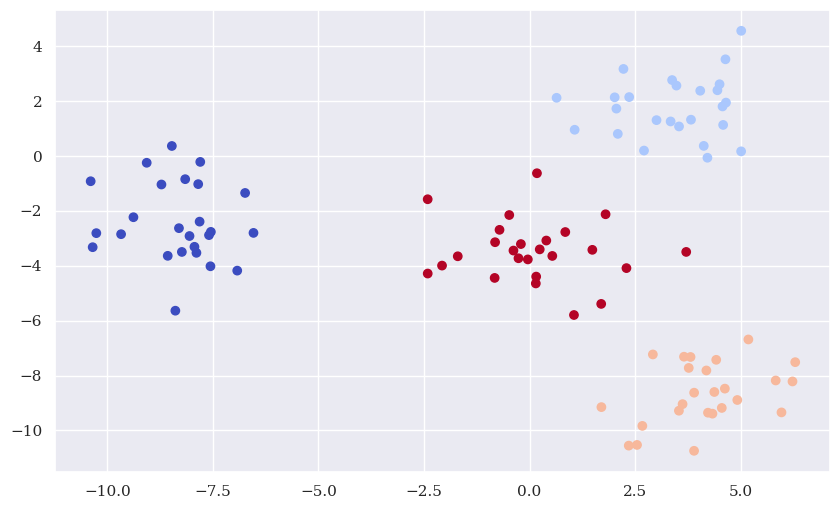

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], x[:, 1], c=y_, cmap='coolwarm')
plt.show()

-- Reinforcement learning -- This is a coin tossing game that is played with a coin that lands 80% of the time on heads and 20% of the time on tails. The baseline algorithm, bets randomly and equally distributes on heads and tails, achieves a total reward of around 50, per epoch of 100 bets played.

In [5]:
ssp = [1, 1, 1, 1, 0]
asp = [1, 0]
def epoch():
  tr = 0
  for _ in range(100):
    a = np.random.choice(asp)
    s = np.random.choice(ssp)
    if a == s:
      tr += 1
  return tr

In [6]:
rl = np.array([epoch() for _ in range(15)])
rl

array([54, 48, 53, 53, 40, 48, 40, 50, 52, 46, 46, 46, 49, 53, 45])

In [7]:
rl.mean()

np.float64(48.2)

In [8]:
ssp = [1, 1, 1, 1, 0]

In [9]:
def epoch():
  tr = 0
  asp = [0, 1]
  for _ in range(100):
    a = np.random.choice(asp)
    s = np.random.choice(ssp)
    if a == s:
      tr += 1
    asp.append(s)
  return tr

In [10]:
rl = np.array([epoch() for _ in range(15)])
rl

array([63, 66, 61, 66, 64, 68, 69, 65, 69, 60, 66, 62, 71, 73, 67])

In [11]:
rl.mean()

np.float64(66.0)

In [12]:
def f(x):
  return 2 * x ** 2 - x ** 3 / 3

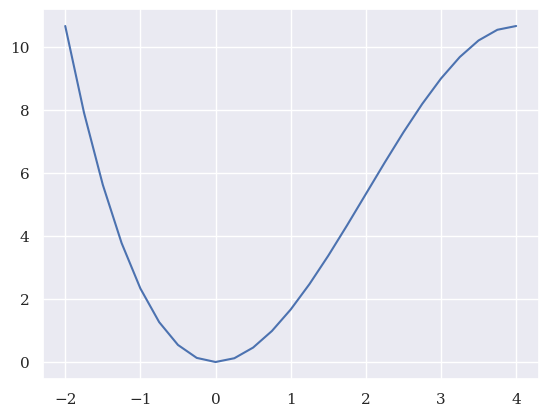

In [13]:
x = np.linspace(-2, 4, 25)
plt.plot(x, f(x))
plt.show()

In [14]:
y = f(x)
y

array([10.6667,  7.9115,  5.625 ,  3.776 ,  2.3333,  1.2656,  0.5417,
        0.1302,  0.    ,  0.1198,  0.4583,  0.9844,  1.6667,  2.474 ,
        3.375 ,  4.3385,  5.3333,  6.3281,  7.2917,  8.1927,  9.    ,
        9.6823, 10.2083, 10.5469, 10.6667])

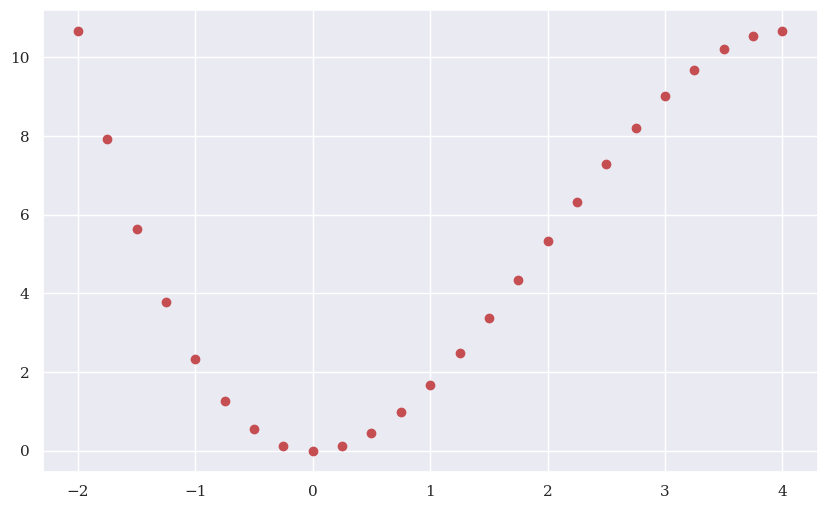

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro')
plt.show()

In [16]:
beta = np.cov(x, y, ddof=0)[0, 1] / np.var(x)
beta

np.float64(1.0541666666666667)

In [17]:
alpha = y.mean() - beta * x.mean()
alpha

np.float64(3.8625000000000003)

In [18]:
y_ = alpha + beta * x

In [19]:
MSE = ((y - y_) ** 2).mean()
MSE

np.float64(10.721953125)

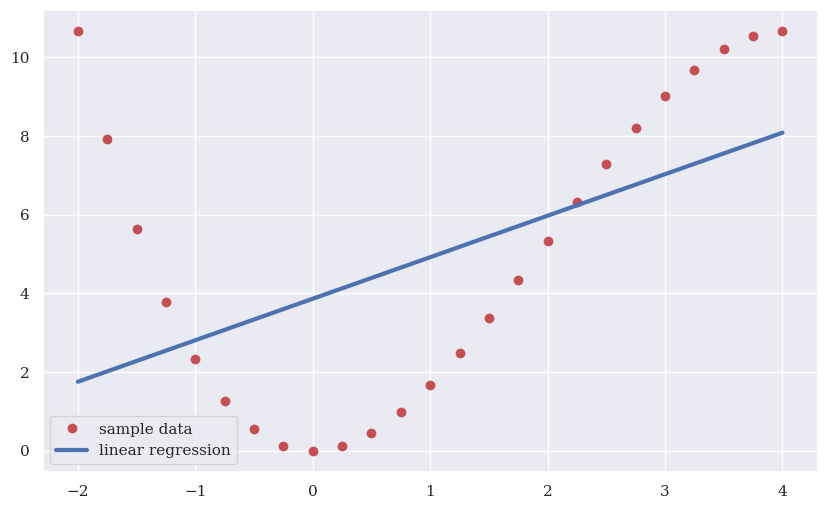

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
plt.plot(x, y_, lw=3.0, label='linear regression')
plt.legend();

Degree 1 (Linear Regression)
Degree 2 (Quadratic Regression)
Degree 3 (Cubic Regression)

deg=1 | MSE=10.72195
deg=2 | MSE=2.31258
deg=3 | MSE=0.00000


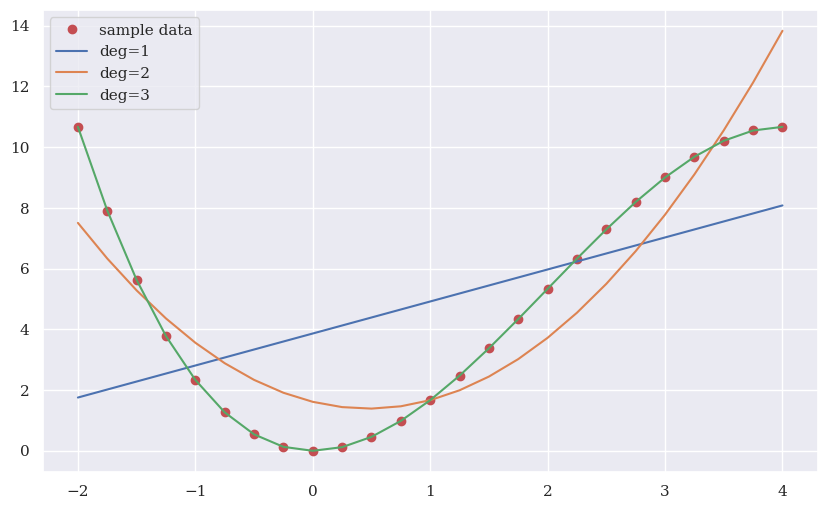

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for deg in [1, 2, 3]:
  reg = np.polyfit(x, y, deg=deg)
  y_ = np.polyval(reg, x)
  MSE = ((y - y_) ** 2).mean()
  print(f'deg={deg} | MSE={MSE:.5f}')
  plt.plot(x, np.polyval(reg, x), label=f'deg={deg}')
plt.legend();

In [22]:
reg

array([-0.3333,  2.    ,  0.    , -0.    ])

In [23]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(hidden_layer_sizes=3 * [256],
                     learning_rate_init=0.03,
                     max_iter=5000)

In [24]:
model.fit(x.reshape(-1, 1), y)
y_ = model.predict(x.reshape(-1, 1))

In [25]:
MSE = ((y - y_) ** 2).mean()
MSE

np.float64(0.0018653926477647698)

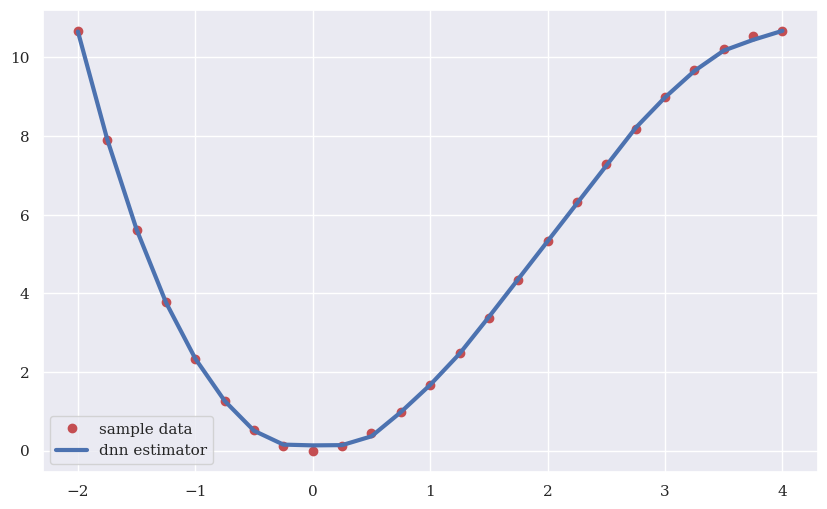

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
plt.plot(x, y_, lw=3.0, label='dnn estimator')
plt.legend();

In [27]:
import tensorflow as tf
tf.random.set_seed(100)

Keras - Deep learning package.
Model is fitted, trained for 100 epochs. The procedure is done for 5 rounds.

In [29]:
from keras.layers import Dense
from keras.models import Sequential
#Using TensorFlow backend.

In [31]:
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=(1)))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='rmsprop')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
((y - y_) ** 2).mean()

np.float64(0.0018653926477647698)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
round=1 | MSE=2.68905
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
round=2 | MSE=0.63688
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
round=3 | MSE=0.17793
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
round=4 | MSE=0.11303
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
round=5 | MSE=0.09626


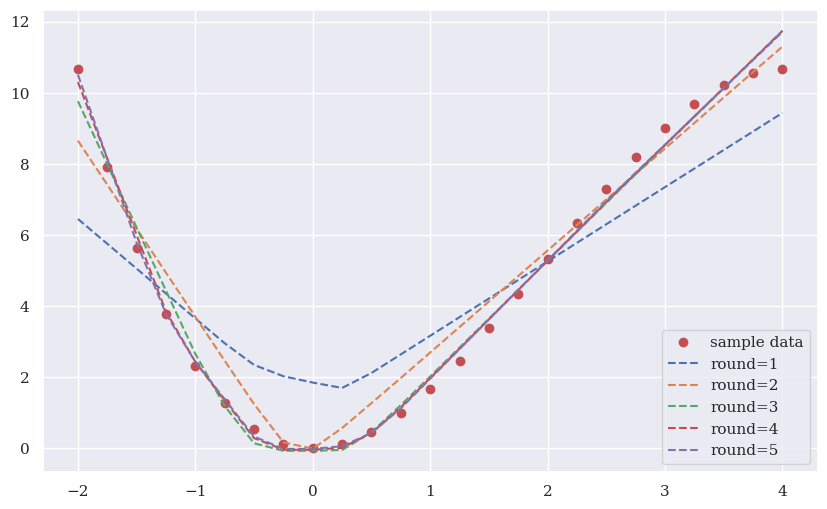

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for _ in range(1, 6):
  model.fit(x, y, epochs=100, verbose=False)
  y_ = model.predict(x)
  MSE = ((y - y_.flatten()) ** 2).mean()
  print(f'round={_} | MSE={MSE:.5f}')
  plt.plot(x, y_, '--', label=f'round={_}')
plt.legend();

In [38]:
np.random.seed(0)
x = np.linspace(-1, 1)
y = np.random.random(len(x)) * 2 - 1

deg= 1 | MSE=0.28153
deg= 5 | MSE=0.27331
deg= 9 | MSE=0.25442
deg=11 | MSE=0.23458
deg=13 | MSE=0.22989
deg=15 | MSE=0.21672


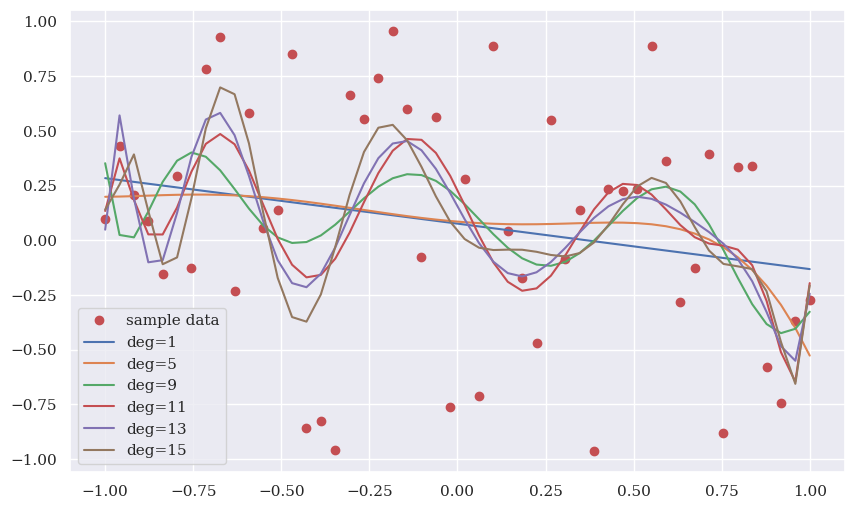

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for deg in [1,5,9,11,13,15]:
  reg = np.polyfit(x, y, deg=deg)
  y_ = np.polyval(reg, x)
  MSE = ((y - y_) ** 2).mean()
  print(f'deg={deg:2d} | MSE={MSE:.5f}')
  plt.plot(x, np.polyval(reg, x), label=f'deg={deg}')
plt.legend();

In [42]:
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=(1)))
for _ in range(3):
  model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='rmsprop')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.summary()
Model:"sequential_2"

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,145 (774.00 KB)

 Trainable params: 198,145 (774.00 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
round=1 | MSE=0.16166
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
round=2 | MSE=0.13469
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
round=3 | MSE=0.12120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
round=4 | MSE=0.05807
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
round=5 | MSE=0.08081
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
round=6 | MSE=0.03331
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
round=7 | MSE=0.01306
CPU times: user 2min 18s, sys: 4.18 s, total: 2min 22s
Wall time: 2min 15s


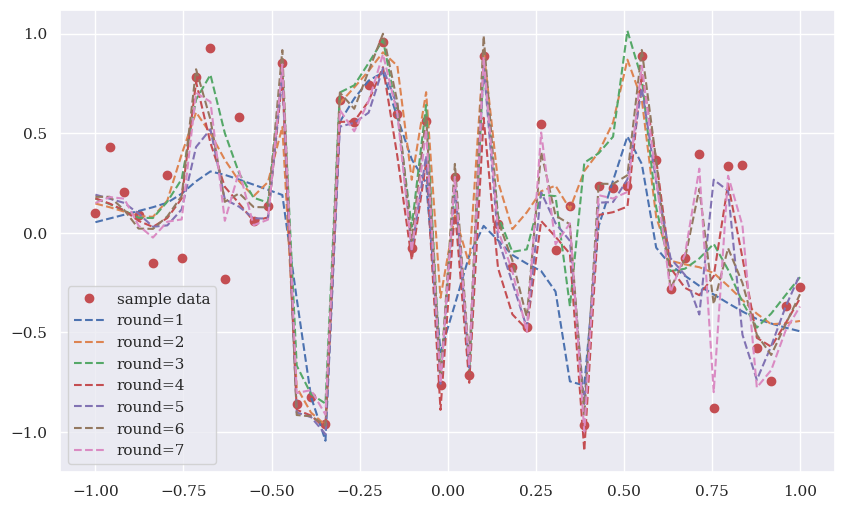

In [44]:
%%time
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='sample data')
for _ in range(1, 8):
  model.fit(x, y, epochs=500, verbose=False)
  y_ = model.predict(x)
  MSE = ((y - y_.flatten()) ** 2).mean()
  print(f'round={_} | MSE={MSE:.5f}')
  plt.plot(x, y_, '--', label=f'round={_}')
plt.legend();